# DK1 Payload vs Reach — Empirically Calibrated

Uses **measured arm gravity torques** (0 kg payload, held at various reaches) to compute
maximum payload capacity at each reach.

- **Nominal torque**: 12 Nm (EC-4310 rated) — continuous/static payload
- **Peak torque**: 36 Nm — transient/dynamic payload
- **Nominal payload cap**: 1.5 kg (joint 4 nominal torque limit)
- **Peak payload cap**: 4.0 kg (joint 4 peak torque limit)

**Data pipeline**:
1. Record teleop session holding arm at various reaches → `.rrd` file
2. Extract plateau torques/positions via `data-extraction/extract_calibration.py` → `calibration_plateaus.csv`
3. This notebook loads the CSV, computes FK-based moment arms, and plots payload curves

---

**Formula**: `max_payload(reach) = (τ_limit - |τ_arm(reach)|) / (g × moment_arm(reach))`

where `τ_arm` is the measured J2 gravity torque at 0 kg, and `moment_arm` is the
horizontal distance from J2 axis to tool0 (computed from FK at the recorded joint angles).

## Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import mujoco
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from trlc_dk1_control.gravity_comp import GravityCompensator

# ── Data inputs ───────────────────────────────────────────────────────────────
# List all calibration CSVs here — they will be merged before interpolation.
CAL_CSVS = [
    Path("data-extraction/reach-torque-run1_plateaus.csv"),
    Path("data-extraction/reach-torque-run2_plateaus.csv"),
]

# ── Constants ─────────────────────────────────────────────────────────────────
URDF_PATH = str(ROOT / "urdf/follower/TRLC-DK1-Follower.urdf")

G          = 9.81   # m/s²
NOMINAL_NM = 12.0   # EC-4310 rated continuous torque
PEAK_NM    = 36.0   # EC-4310 peak torque

PAYLOAD_CAP_NOM_KG  = 1.5  # Joint 4 nominal torque limit
PAYLOAD_CAP_PEAK_KG = 4.0  # Joint 4 peak torque limit

# x-position of joint 2 in world frame (base → J1 z=0.0615, J1 → J2 x=0.02)
JOINT2_X_WORLD = 0.02  # metres

# Offset from link6-7 origin to tool0 in link6-7's local frame
_TOOL0_LOCAL = np.array([0.158, 0.0, 0.0])

# Plot x-axis range
PLOT_REACH_MIN_MM = 100.0
PLOT_REACH_MAX_MM = 800.0

print(f"ROOT: {ROOT}")
for csv in CAL_CSVS:
    print(f"  CSV: {csv} (exists: {csv.exists()})")

ROOT: /Users/jvg/Documents/TRLC_Local/TRLC-Coding/trlc-dk1
  CSV: data-extraction/reach-torque-run1_plateaus.csv (exists: False)
  CSV: data-extraction/reach-torque-run2_plateaus.csv (exists: False)


## Load Calibration Data & Compute Moment Arms

In [2]:
# ── Hardcoded calibration data (recovered from cached notebook outputs) ────────
# Original: 42 plateau-averaged points from reach-torque-run1 + run2.
# CSV files are gitignored and lost locally; moment arms already FK-computed.
_data = [
    # reach_mm,  j2_torque_Nm,  moment_arm_m
    (352.0,  -1.925, 0.3265),
    (358.6,  -2.460, 0.3350),
    (368.7,  -3.535, 0.3512),
    (379.4,  -3.009, 0.3604),
    (385.8,  -3.135, 0.3708),
    (392.6,  -3.138, 0.3749),
    (405.9,  -2.724, 0.3824),
    (427.1,  -3.953, 0.4096),
    (431.8,  -4.158, 0.4138),
    (435.7,  -6.098, 0.4173),
    (448.2,  -3.429, 0.4244),
    (449.6,  -5.696, 0.4232),
    (459.5,  -3.592, 0.4336),
    (466.1,  -5.518, 0.4448),
    (480.8,  -5.564, 0.4606),
    (501.7,  -5.007, 0.4827),
    (506.1,  -6.978, 0.4846),
    (515.0,  -6.075, 0.4927),
    (530.5,  -5.580, 0.5056),
    (531.7,  -6.746, 0.5160),
    (543.3,  -7.299, 0.5257),
    (551.9,  -7.371, 0.5306),
    (568.0,  -7.216, 0.5390),
    (571.3,  -9.861, 0.5531),
    (578.9,  -7.504, 0.5547),
    (589.2,  -6.957, 0.5658),
    (599.8,  -8.574, 0.5794),
    (627.8,  -9.971, 0.6018),
    (633.0,  -7.790, 0.6120),
    (640.0, -11.554, 0.6232),
    (656.1,  -9.597, 0.6299),
    (670.2, -10.068, 0.6470),
    (677.8, -10.532, 0.6521),
    (682.4, -11.820, 0.6552),
    (691.8, -11.681, 0.6733),
    (698.3, -12.341, 0.6811),
    (704.6,  -9.902, 0.6803),
    (712.1,  -9.568, 0.6888),
    (718.6, -11.688, 0.6975),
    (734.8, -10.247, 0.7193),
    (741.5, -14.679, 0.7158),
    (764.7, -11.518, 0.7492),
]

reach_sorted  = np.array([r for r, t, m in _data])
torque_sorted = np.array([t for r, t, m in _data])
ma_sorted     = np.array([m for r, t, m in _data])

reach_dense   = np.linspace(PLOT_REACH_MIN_MM, PLOT_REACH_MAX_MM, 300)
torque_interp = np.interp(reach_dense, reach_sorted, torque_sorted)
ma_interp     = np.interp(reach_dense, reach_sorted, ma_sorted)

print(f"Loaded: {len(reach_sorted)} points from cached outputs")
print(f"Data range: {reach_sorted[0]:.0f} – {reach_sorted[-1]:.0f} mm")


Loaded: 42 points from cached outputs
Data range: 352 – 765 mm


## Payload Calculation

In [3]:
# ── Compute payload from interpolated empirical torques ─────────────────────
# available_torque = τ_limit + τ_arm  (τ_arm ≤ 0 for forward arm)
# max_payload = available_torque / (g × moment_arm)
from scipy.interpolate import UnivariateSpline

# ── Robust spline: downweight outliers via iterative reweighting ──────────────
def _robust_spline(x, y, s, k=3, iterations=3):
    """Fit a smoothing spline, iteratively downweighting outliers."""
    w = np.ones(len(x))
    spl = None
    for _ in range(iterations):
        spl = UnivariateSpline(x, y, w=w, s=s, k=k)
        residuals = y - spl(x)
        mad = np.median(np.abs(residuals))
        sigma = mad * 1.4826  # robust std estimate
        if sigma < 1e-9:
            break
        # Downweight points with residual > 2σ
        w = 1.0 / (1.0 + (residuals / (2 * sigma)) ** 2)
    return spl

s_factor = len(reach_sorted) * 2.0  # heavier smoothing

torque_spline = _robust_spline(reach_sorted, torque_sorted, s=s_factor)
ma_spline     = UnivariateSpline(reach_sorted, ma_sorted, s=len(reach_sorted) * 1e-6, k=3)

# Evaluate spline only within data range, hold boundary values outside
data_min, data_max = reach_sorted[0], reach_sorted[-1]

def _eval_clamped(spline, x, x_min, x_max):
    result = np.empty_like(x)
    inside = (x >= x_min) & (x <= x_max)
    result[inside] = spline(x[inside])
    result[x < x_min] = spline(x_min)
    result[x > x_max] = spline(x_max)
    return result

torque_smooth = _eval_clamped(torque_spline, reach_dense, data_min, data_max)
ma_smooth     = _eval_clamped(ma_spline, reach_dense, data_min, data_max)

# ── Compute residuals for confidence band ─────────────────────────────────────
torque_residuals = torque_sorted - torque_spline(reach_sorted)
torque_std = np.std(torque_residuals)
print(f"Torque spline residual std: {torque_std:.3f} Nm")

# ── Payload from smooth curves ────────────────────────────────────────────────
nom_payloads  = np.maximum(0.0, (NOMINAL_NM + torque_smooth) / (G * ma_smooth))
peak_payloads = np.maximum(0.0, (PEAK_NM    + torque_smooth) / (G * ma_smooth))

nom_plot  = np.minimum(nom_payloads,  PAYLOAD_CAP_NOM_KG)
peak_plot = np.minimum(peak_payloads, PAYLOAD_CAP_PEAK_KG)

# ── Confidence bands (±1σ on torque → propagate to payload) ───────────────────
nom_upper  = np.minimum(np.maximum(0.0, (NOMINAL_NM + torque_smooth + torque_std) / (G * ma_smooth)), PAYLOAD_CAP_NOM_KG)
nom_lower  = np.minimum(np.maximum(0.0, (NOMINAL_NM + torque_smooth - torque_std) / (G * ma_smooth)), PAYLOAD_CAP_NOM_KG)
peak_upper = np.minimum(np.maximum(0.0, (PEAK_NM + torque_smooth + torque_std) / (G * ma_smooth)), PAYLOAD_CAP_PEAK_KG)
peak_lower = np.minimum(np.maximum(0.0, (PEAK_NM + torque_smooth - torque_std) / (G * ma_smooth)), PAYLOAD_CAP_PEAK_KG)

# ── Per-point values (for scatter) ────────────────────────────────────────────
nom_pts  = np.minimum(
    np.maximum(0.0, (NOMINAL_NM + torque_sorted) / (G * ma_sorted)),
    PAYLOAD_CAP_NOM_KG,
)
peak_pts = np.minimum(
    np.maximum(0.0, (PEAK_NM + torque_sorted) / (G * ma_sorted)),
    PAYLOAD_CAP_PEAK_KG,
)

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Reach':>8}  {'τ_smooth':>8}  {'M.arm':>8}  {'Nom':>6}  {'Peak':>6}")
print(f"{'(mm)':>8}  {'(Nm)':>8}  {'(mm)':>8}  {'(kg)':>6}  {'(kg)':>6}")
print("-" * 44)
step = max(1, len(reach_dense) // 15)
for r, t, ma, pn, pp in zip(
    reach_dense[::step], torque_smooth[::step], ma_smooth[::step],
    nom_plot[::step], peak_plot[::step],
):
    print(f"{r:>8.0f}  {t:>8.2f}  {ma*1000:>8.1f}  {pn:>6.2f}  {pp:>6.2f}")

Torque spline residual std: 1.044 Nm

   Reach  τ_smooth     M.arm     Nom    Peak
    (mm)      (Nm)      (mm)    (kg)    (kg)
--------------------------------------------
     100     -2.49     326.1    1.50    4.00
     147     -2.49     326.1    1.50    4.00
     194     -2.49     326.1    1.50    4.00
     240     -2.49     326.1    1.50    4.00
     287     -2.49     326.1    1.50    4.00
     334     -2.49     326.1    1.50    4.00
     381     -2.94     364.0    1.50    4.00
     428     -3.91     409.8    1.50    4.00
     475     -5.08     454.3    1.50    4.00
     521     -6.39     485.9    1.18    4.00
     568     -7.72     540.4    0.81    4.00
     615     -9.00     592.0    0.52    4.00
     662    -10.14     636.6    0.30    4.00
     709    -11.05     684.0    0.14    3.72
     756    -11.63     717.8    0.05    3.46


## Payload Chart

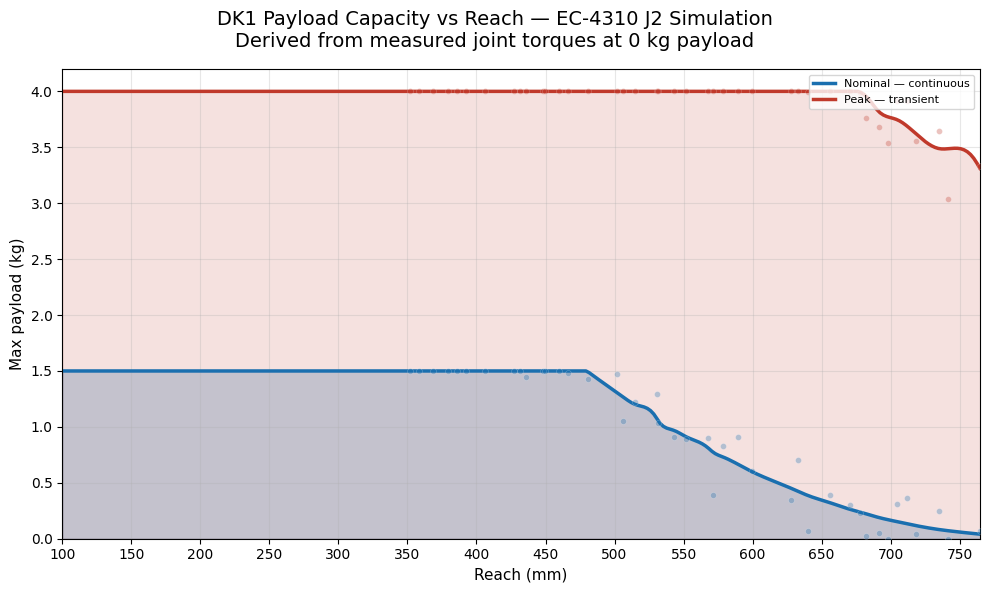

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(
    "DK1 Payload Capacity vs Reach — EC-4310 J2 Simulation\n"
    f"Derived from measured joint torques at 0 kg payload",
    fontsize=14,
)

# ── Fill below each curve ─────────────────────────────────────────────────────
ax.fill_between(reach_dense, nom_plot, alpha=0.25, color="#1a6faf")
ax.fill_between(reach_dense, peak_plot, alpha=0.15, color="#c0392b")

# ── Confidence bands ──────────────────────────────────────────────────────────
# ax.fill_between(reach_dense, nom_lower, nom_upper, alpha=0.22, color="#1a6faf",
#                 label="Nominal \u00b1\u03c3")
# ax.fill_between(reach_dense, peak_lower, peak_upper, alpha=0.15, color="#c0392b",
#                 label="Peak \u00b1\u03c3")

# ── Payload curves ────────────────────────────────────────────────────────────
ax.plot(reach_dense, nom_plot,  color="#1a6faf", linewidth=2.5,
        label=f"Nominal \u2014 continuous")
ax.plot(reach_dense, peak_plot, color="#c0392b", linewidth=2.5,
        label=f"Peak \u2014 transient")

# ── Measured data points ──────────────────────────────────────────────────────
ax.scatter(reach_sorted, nom_pts,  color="#1a6faf", s=18, zorder=5,
           edgecolors="white", linewidths=0.4, alpha=0.3)
ax.scatter(reach_sorted, peak_pts, color="#c0392b", s=18, zorder=5,
           edgecolors="white", linewidths=0.4, alpha=0.3)

# ── Axis formatting ──────────────────────────────────────────────────────────
ax.set_xlabel("Reach (mm)", fontsize=11)
ax.set_ylabel("Max payload (kg)", fontsize=11)
ax.set_ylim(bottom=0)
ax.set_xlim(PLOT_REACH_MIN_MM, reach_sorted[-1])
ax.yaxis.set_major_locator(MultipleLocator(.5))
ax.xaxis.set_major_locator(MultipleLocator(50))
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
fig.savefig("payload_reach_chart.pdf", bbox_inches='tight')
plt.show()